In [5]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, LSTM, Dense, Dropout, BatchNormalization, TimeDistributed, Flatten,Reshape, Input, GlobalAveragePooling2D, Concatenate)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

MULTI-SCALE CNN-LSTM FOR LEUKEMIA DETECTION
Found 2607 images belonging to 4 classes.
Found 649 images belonging to 4 classes.

📊 Dataset Information:
  Classes: {'Benign': 0, 'Early': 1, 'Pre': 2, 'Pro': 3}
  Training samples: 2607
  Validation samples: 649
  Number of classes: 4

🔨 Building Multi-Scale CNN-LSTM Model...

📋 Model Architecture:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 64, 64,    │          0 │ max_pooling2d_12… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 64, 64,    │     18,496 │ dropout_15[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 64, 64,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 32, 32,    │          0 │ max_pooling2d_13… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 32, 32,    │     73,856 │ dropout_16[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 32, 32,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_29[0][0] 

 Total params: 1,499,428 (5.72 MB)

 Trainable params: 1,496,996 (5.71 MB)

 Non-trainable params: 2,432 (9.50 KB)


 Total trainable parameters: 1,496,996

🚀 TRAINING STARTED

Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.5891 - loss: 0.9739 - precision: 0.6588 - recall: 0.5079
Epoch 1: val_accuracy improved from None to 0.30354, saving model to best_multiscale_cnn_lstm.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 612ms/step - accuracy: 0.7238 - loss: 0.6911 - precision: 0.7834 - recall: 0.6632 - val_accuracy: 0.3035 - val_loss: 1.3849 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.9006 - loss: 0.3225 - precision: 0.9126 - recall: 0.8809
Epoch 2: val_accuracy improved from 0.30354 to 0.33898, saving model to best_multiscale_cnn_lstm.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 606ms/step - accuracy: 0.9053 - loss: 0.2961 - precision: 0.9169 - recall: 0.8849 - val_accuracy: 0.3390 - val_loss: 1.3221 - val_precision: 1.0000 - val_recall: 0.0200 - learning_rate: 1.0000e-04
Epoch 3/50
163/16

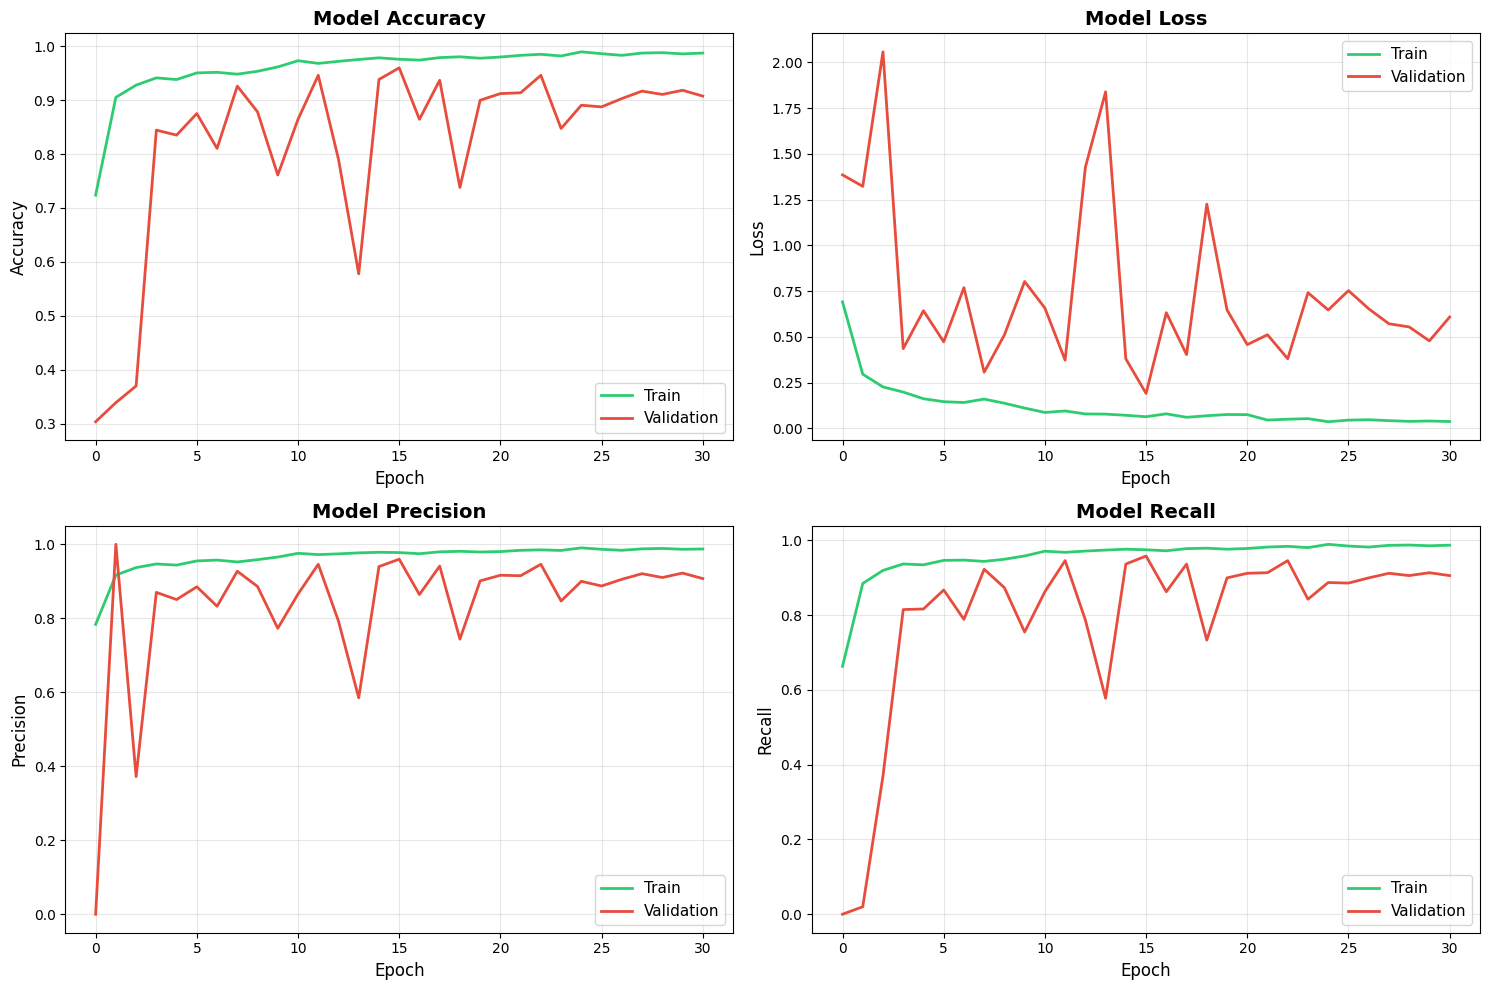


✨ TRAINING COMPLETE!

Next Steps:
1. Use improved_prediction.py to test your model
2. Generate confusion matrix for your thesis
3. Compare with other models (Transfer Learning, Pure CNN)
4. Document the multi-scale approach in your report

Model saved to:
- best_multiscale_cnn_lstm.keras (best weights during training)
- multiscale_cnn_lstm_final.keras (final weights)



In [6]:
def create_multiscale_cnn_lstm(img_size=(128, 128, 3), num_classes=4):
    """
    Multi-Scale CNN-LSTM for Leukemia Detection
    
    FIXED VERSION - All errors resolved
    """
    inputs = Input(shape=img_size)
    
    # ========== CNN Feature Extractor ==========
    # Block 1 - Low-level features
    x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    scale1 = GlobalAveragePooling2D()(x)  # Shape: (batch, 32)
    
    # Block 2 - Mid-level features
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    scale2 = GlobalAveragePooling2D()(x)  # Shape: (batch, 64)
    
    # Block 3 - High-level features
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    scale3 = GlobalAveragePooling2D()(x)  # Shape: (batch, 128)
    
    # Block 4 - Very high-level features
    x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    scale4 = GlobalAveragePooling2D()(x)  # Shape: (batch, 256)
    
    # ========== Normalize feature dimensions ==========
    scale1_dense = Dense(256)(scale1)  # 32 → 256
    scale2_dense = Dense(256)(scale2)  # 64 → 256
    scale3_dense = Dense(256)(scale3)  # 128 → 256
    scale4_dense = scale4                # Already 256
    
    # ========== Create Sequence for LSTM (FIXED) ==========
    # Reshape each scale to (batch, 1, 256)
    scale1_reshaped = Reshape((1, 256))(scale1_dense)
    scale2_reshaped = Reshape((1, 256))(scale2_dense)
    scale3_reshaped = Reshape((1, 256))(scale3_dense)
    scale4_reshaped = Reshape((1, 256))(scale4_dense)
    
    # Concatenate along time axis to create sequence
    feature_sequence = Concatenate(axis=1)([scale1_reshaped, scale2_reshaped, 
                                            scale3_reshaped, scale4_reshaped])
    # Shape: (batch, 4, 256) - 4 timesteps, 256 features each
    
    # ========== LSTM Layer ==========
    lstm_out = LSTM(128, return_sequences=True)(feature_sequence)
    lstm_out = Dropout(0.4)(lstm_out)
    lstm_out = LSTM(64, return_sequences=False)(lstm_out)
    lstm_out = Dropout(0.4)(lstm_out)
    
    # ========== Classification Head ==========
    dense = Dense(256, activation='relu')(lstm_out)
    dense = BatchNormalization()(dense)
    dense = Dropout(0.5)(dense)
    outputs = Dense(num_classes, activation='softmax')(dense)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model


# ============================================================================
# TRAINING SCRIPT
# ============================================================================

# Dataset path
DATASET_PATH = r"C:\Users\rauna\Desktop\Main_Project\datasets\ALL blood"

# Hyperparameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 0.0001

print("=" * 70)
print("MULTI-SCALE CNN-LSTM FOR LEUKEMIA DETECTION")
print("=" * 70)

# ========== Data Generators ==========
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

num_classes = train_generator.num_classes
print(f"\n📊 Dataset Information:")
print(f"  Classes: {train_generator.class_indices}")
print(f"  Training samples: {train_generator.samples}")
print(f"  Validation samples: {val_generator.samples}")
print(f"  Number of classes: {num_classes}")
print("=" * 70)

# ========== Create Model (FIXED) ==========
print("\n🔨 Building Multi-Scale CNN-LSTM Model...")
# IMPORTANT: Pass (128, 128, 3) not just (128, 128)
model = create_multiscale_cnn_lstm(img_size=(128, 128, 3), num_classes=num_classes)

# Compile
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'), 
             tf.keras.metrics.Recall(name='recall')]
)

print("\n📋 Model Architecture:")
print("=" * 70)
model.summary()
print("=" * 70)

# Count trainable parameters
trainable_params = np.sum([K.count_params(w) for w in model.trainable_weights])
print(f"\n Total trainable parameters: {trainable_params:,}")
print("=" * 70)

# ========== Callbacks ==========
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_multiscale_cnn_lstm.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ========== Train Model ==========
print("\n" + "=" * 70)
print("🚀 TRAINING STARTED")
print("=" * 70 + "\n")

try:
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )
    
    # Save final model
    model.save("multiscale_cnn_lstm_final.keras")
    print("\n✅ Model saved as 'multiscale_cnn_lstm_final.keras'")
    
except Exception as e:
    print(f"\n❌ Training error: {e}")
    import traceback
    traceback.print_exc()
    raise

# ========== Evaluation ==========
print("\n" + "=" * 70)
print("📊 FINAL EVALUATION")
print("=" * 70)

try:
    results = model.evaluate(val_generator, verbose=0)
    print(f"\n  Loss:      {results[0]:.4f}")
    print(f"  Accuracy:  {results[1]*100:.2f}%")
    print(f"  Precision: {results[2]:.4f}")
    print(f"  Recall:    {results[3]:.4f}")
    
    # Calculate F1-Score
    f1_score = 2 * (results[2] * results[3]) / (results[2] + results[3]) if (results[2] + results[3]) > 0 else 0
    print(f"  F1-Score:  {f1_score:.4f}")
    print("=" * 70)
    
except Exception as e:
    print(f"❌ Evaluation error: {e}")

# ========== Plot Training History ==========
import matplotlib.pyplot as plt

try:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2, color='#2ecc71')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2, color='#e74c3c')
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Accuracy', fontsize=12)
    axes[0, 0].legend(fontsize=11)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Loss
    axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2, color='#2ecc71')
    axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2, color='#e74c3c')
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Loss', fontsize=12)
    axes[0, 1].legend(fontsize=11)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Train', linewidth=2, color='#2ecc71')
    axes[1, 0].plot(history.history['val_precision'], label='Validation', linewidth=2, color='#e74c3c')
    axes[1, 0].set_title('Model Precision', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Precision', fontsize=12)
    axes[1, 0].legend(fontsize=11)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Train', linewidth=2, color='#2ecc71')
    axes[1, 1].plot(history.history['val_recall'], label='Validation', linewidth=2, color='#e74c3c')
    axes[1, 1].set_title('Model Recall', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Recall', fontsize=12)
    axes[1, 1].legend(fontsize=11)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('multiscale_cnn_lstm_training_history.png', dpi=300, bbox_inches='tight')
    print("\n📈 Training plots saved as 'multiscale_cnn_lstm_training_history.png'")
    plt.show()
    
except Exception as e:
    print(f"⚠️  Could not generate plots: {e}")

print("\n" + "=" * 70)
print("✨ TRAINING COMPLETE!")
print("=" * 70)
print("""
Next Steps:
1. Use improved_prediction.py to test your model
2. Generate confusion matrix for your thesis
3. Compare with other models (Transfer Learning, Pure CNN)
4. Document the multi-scale approach in your report

Model saved to:
- best_multiscale_cnn_lstm.keras (best weights during training)
- multiscale_cnn_lstm_final.keras (final weights)
""")







📌 EXAMPLE 1: Single Image Prediction

Image: WBC-Benign-002.jpg
🎯 Predicted Class: Benign
📊 Confidence: 99.95%

All Class Probabilities:
  Benign  : 99.95% █████████████████████████████████████████████████
  Early   :  0.04% 
  Pre     :  0.00% 
  Pro     :  0.00% 



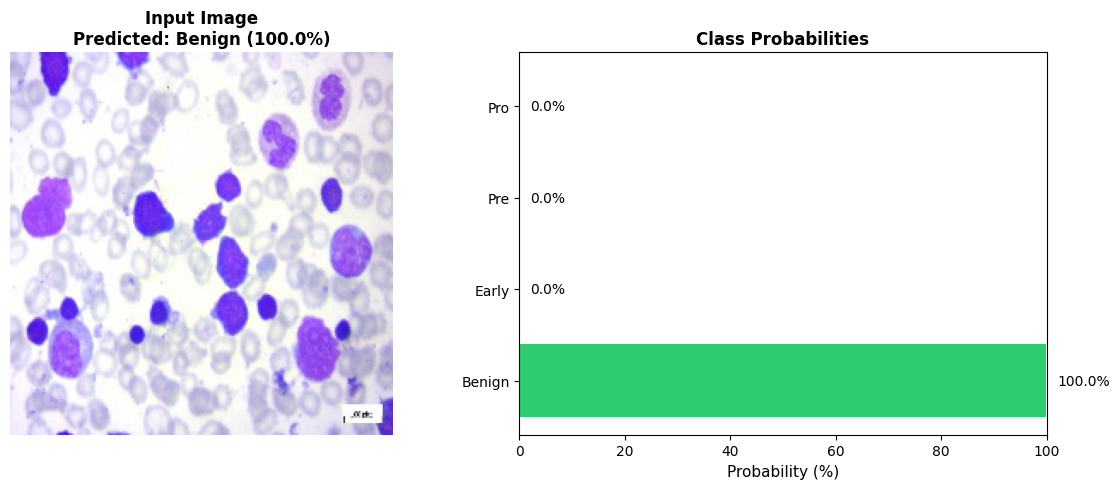

In [4]:
from tensorflow.keras.models import load_model
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

# Load trained model
model = load_model("multiscale_cnn_lstm_final.keras")  # or "leukemia_multiclass_improved.keras"

# Class labels (MUST match training folder order)
class_labels = ["Benign", "Early", "Pre", "Pro"]

# ============== SINGLE IMAGE PREDICTION ==============
def predict_single_image(image_path, show_image=True):
    """
    Predict class for a single image with visualization
    """
    # Read and preprocess image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image at {image_path}")
        return None
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    img_normalized = img_resized / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)
    
    # Predict
    predictions = model.predict(img_batch, verbose=0)
    class_probabilities = predictions[0]
    predicted_class_idx = np.argmax(class_probabilities)
    predicted_class = class_labels[predicted_class_idx]
    confidence = class_probabilities[predicted_class_idx]
    
    # Display results
    print("\n" + "=" * 60)
    print(f"Image: {os.path.basename(image_path)}")
    print("=" * 60)
    print(f"🎯 Predicted Class: {predicted_class}")
    print(f"📊 Confidence: {confidence * 100:.2f}%")
    print("\nAll Class Probabilities:")
    for i, (label, prob) in enumerate(zip(class_labels, class_probabilities)):
        bar = "█" * int(prob * 50)
        print(f"  {label:8s}: {prob*100:5.2f}% {bar}")
    print("=" * 60 + "\n")
    
    # Visualize
    if show_image:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Original image
        axes[0].imshow(img_rgb)
        axes[0].set_title(f'Input Image\nPredicted: {predicted_class} ({confidence*100:.1f}%)', 
                         fontsize=12, fontweight='bold')
        axes[0].axis('off')
        
        # Probability distribution
        colors = ['#2ecc71' if i == predicted_class_idx else '#3498db' 
                 for i in range(len(class_labels))]
        axes[1].barh(class_labels, class_probabilities * 100, color=colors)
        axes[1].set_xlabel('Probability (%)', fontsize=11)
        axes[1].set_title('Class Probabilities', fontsize=12, fontweight='bold')
        axes[1].set_xlim(0, 100)
        
        for i, (label, prob) in enumerate(zip(class_labels, class_probabilities)):
            axes[1].text(prob * 100 + 2, i, f'{prob*100:.1f}%', 
                        va='center', fontsize=10)
        
        plt.tight_layout()
        plt.show()
    
    return predicted_class, confidence, class_probabilities


# ============== BATCH PREDICTION FROM FOLDER ==============
def predict_from_folder(folder_path, true_label=None):
    """
    Predict all images in a folder
    """
    predictions = []
    confidences = []
    filenames = []
    
    image_files = [f for f in os.listdir(folder_path) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    
    print(f"\nProcessing {len(image_files)} images from {folder_path}...")
    
    for filename in image_files:
        image_path = os.path.join(folder_path, filename)
        img = cv2.imread(image_path)
        if img is None:
            continue
            
        img = cv2.resize(img, (128, 128))
        img = img / 255.0
        img = np.expand_dims(img, axis=0)
        
        pred = model.predict(img, verbose=0)
        class_idx = np.argmax(pred)
        confidence = np.max(pred)
        
        predictions.append(class_labels[class_idx])
        confidences.append(confidence)
        filenames.append(filename)
    
    # Summary
    print(f"\nPrediction Summary:")
    print("=" * 60)
    for label in class_labels:
        count = predictions.count(label)
        percentage = (count / len(predictions)) * 100 if predictions else 0
        print(f"{label:8s}: {count:3d} images ({percentage:5.1f}%)")
    print("=" * 60)
    
    if true_label:
        correct = predictions.count(true_label)
        accuracy = (correct / len(predictions)) * 100 if predictions else 0
        print(f"\nAccuracy for '{true_label}': {accuracy:.2f}% ({correct}/{len(predictions)})")
    
    return predictions, confidences, filenames


# ============== EVALUATE ON ENTIRE VALIDATION SET ==============
def evaluate_validation_set(dataset_path):
    """
    Generate confusion matrix and classification report
    """
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    
    # Create validation generator
    val_datagen = ImageDataGenerator(rescale=1./255)
    val_generator = val_datagen.flow_from_directory(
        dataset_path,
        target_size=(128, 128),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )
    
    # Predict
    print("Generating predictions for validation set...")
    predictions = model.predict(val_generator, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = val_generator.classes
    
    # Confusion Matrix
    cm = confusion_matrix(true_classes, predicted_classes)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Confusion Matrix - Multiclass Leukemia Classification', 
             fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    print("\nConfusion matrix saved as 'confusion_matrix.png'")
    plt.show()
    
    # Classification Report
    print("\n" + "=" * 60)
    print("CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(true_classes, predicted_classes, 
                               target_names=class_labels, digits=4))
    
    return cm, true_classes, predicted_classes


# ============== EXAMPLE USAGE ==============
if __name__ == "__main__":
    
    # Example 1: Predict single image
    print("\n📌 EXAMPLE 1: Single Image Prediction")
    predict_single_image(
        r"datasets/ALL blood/Benign/WBC-Benign-002.jpg",
        show_image=True
    )
    
    
    
    